# 🎛️ Lab 1: First Contact & The Building Blocks (Hello DSP!)

ยินดีต้อนรับสู่ภารกิจแรกของการเรียนรู้ Digital Signal Processing (DSP) ด้วย Python!
ในสัปดาห์นี้เราจะมาทำความเข้าใจว่าคอมพิวเตอร์สร้างและมองเห็น "เสียง" ได้อย่างไร คุณจะได้สร้างคลื่นเสียง ผสมคลื่นเสียงแบบศิลปิน 8-bit และจำลองสัญญาณรบกวน (Noise) ในโลกความเป็นจริง

**🚨 กติกาการใช้งาน (Standard Operating Procedure - SOP):**
1. รันโค้ดทีละเซลล์จากบนลงล่าง (กด `Shift + Enter`)
2. เติมโค้ด Python ของคุณลงในบรรทัดที่มีคำว่า `### YOUR CODE HERE ###` เพื่อให้โปรแกรมทำงานได้สมบูรณ์
3. สังเกตผลลัพธ์จากกราฟและเสียงที่ได้

---
## Phase 1: เตรียมเครื่องมือ (The Toolkits)

In [1]:
# Import ไลบรารีที่จำเป็นสำหรับภารกิจนี้
import numpy as np                  # สำหรับจัดการข้อมูลตัวเลขและอาร์เรย์ (Array)
import matplotlib.pyplot as plt     # สำหรับวาดกราฟ
from IPython.display import Audio   # สำหรับสร้างเครื่องเล่นเสียงใน Colab

print("Libraries imported successfully! พร้อมลุยภารกิจต่อไป")

Libraries imported successfully! พร้อมลุยภารกิจต่อไป


---
## ภารกิจที่ 1: สรรค์สร้างเวลา (Time Vector)
สัญญาณดิจิทัลคือข้อมูลที่ถูกเก็บเป็น "จุด" ต่อเนื่องกันไปตามเวลา สิ่งแรกที่เราต้องทำคือการสร้าง "แกนเวลา (Time Axis)" ขึ้นมา

* **Sampling Rate ($f_s$):** จำนวนจุดข้อมูลใน 1 วินาที (มาตรฐานแผ่นซีดีคือ 44,100 จุด/วินาที)
* **Duration:** ความยาวของเสียงที่เราต้องการ (วินาที)

In [4]:
fs = 44100          # Sampling Rate: 44100 Hz
duration = 1.0      # ความยาวเสียง: 1 วินาที
num_samples = int(fs * duration) # จำนวนจุดข้อมูลทั้งหมด

# MISSION 1: สร้าง Array ของเวลา 't' ตั้งแต่ 0 ถึง 1 วินาที ให้มีจำนวนจุดเท่ากับ num_samples
# Hint: ใช้ฟังก์ชัน np.linspace(จุดเริ่มต้น, จุดสิ้นสุด, จำนวนจุด)
t = np.linspace(0, duration, num_samples, endpoint=False)

print(f"สร้างแกนเวลาสำเร็จ! จำนวนจุดข้อมูลทั้งหมด: {len(t)} จุด")
print(f"ข้อมูล 5 จุดแรกคือ: {t[:5]}")

สร้างแกนเวลาสำเร็จ! จำนวนจุดข้อมูลทั้งหมด: 44100 จุด
ข้อมูล 5 จุดแรกคือ: [0.00000000e+00 2.26757370e-05 4.53514739e-05 6.80272109e-05
 9.07029478e-05]


---
## ภารกิจที่ 2: ปลุกชีพเสียง (Signal Generation)
เมื่อเรามีเวลาแล้ว ต่อไปเราจะสร้าง "คลื่น" (Wave) ขึ้นมาเกาะบนแกนเวลานั้น
สมการทางคณิตศาสตร์ของคลื่นเสียง (Sine Wave) พื้นฐานคือ:
$$y(t) = A \cdot \sin(2 \cdot \pi \cdot f \cdot t)$$

* $A$ = แอมพลิจูด (ความดัง)
* $f$ = ความถี่ (ระดับเสียงแหลม/ทุ้ม หน่วยเป็น Hz)

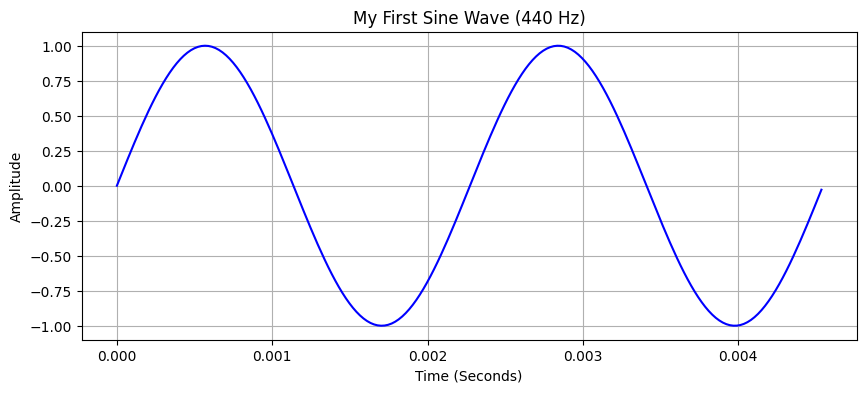

In [18]:
f = 440.0   # ความถี่ 440 Hz (เสียงโน้ต A4 หรือเสียงตั้งสายกีตาร์)
A = 1.0     # แอมพลิจูดสูงสุด (ความดัง)

# MISSION 2: แปลงสมการคณิตศาสตร์ด้านบนให้เป็นโค้ด Python
# Hint: ค่า pi ใช้ np.pi และฟังก์ชัน sin ใช้ np.sin()
y = A * np.sin(2 * np.pi * f * t)

# มาดูกราฟหน้าตาคลื่นที่เราสร้างขึ้น (พล็อตแค่ 0.01 วินาทีแรกให้เห็นคลื่นชัดๆ)
plt.figure(figsize=(10, 4))
plt.plot(t[:201], y[:201], color='blue') # 441 จุด = 0.01 วินาที
plt.title("My First Sine Wave (440 Hz)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

---
## ภารกิจที่ 3: เปิดโสตประสาท (Let's Hear It!)
กราฟอาจจะดูสวยดี แต่ DSP คือเรื่องของเสียง! ลองนำข้อมูล `y` ที่เราสร้างไปแปลงเป็นเสียงกันดู

In [8]:
# MISSION 3: ใส่ตัวแปรคลื่นเสียงของเราลงไปในฟังก์ชัน Audio แทนที่คำว่า ### YOUR CODE HERE ###
display(Audio(data=A * np.sin(2 * np.pi * f * t), rate=fs))

**🔥 Mini-Challenge:** ลองย้อนกลับไปที่ Code Cell ของภารกิจที่ 2 แล้วเปลี่ยนค่าความถี่ `f` ให้เป็น `880` (เสียงสูงขึ้น) หรือ `220` (เสียงต่ำลง) แล้วรันเซลล์ลงมาใหม่เรื่อยๆ เพื่อฟังความแตกต่าง!

---
## ภารกิจที่ 4: ภาพลวงตาแห่งฟูเรียร์ (The Fourier Illusion)
รู้หรือไม่? คลื่นสี่เหลี่ยม (Square Wave) สุดเท่ที่ใช้ในเสียงดนตรีเกม 8-bit ยุคคลาสสิก แท้จริงแล้วเกิดจาก **"คลื่น Sine Wave โค้งๆ หลายๆ ความถี่มารวมร่างกัน"** (นี่คือหลักการเบื้องต้นของ Fourier Series)

สมการการรวมร่างคือ:
$$y_{square}(t) = \sin(2\pi f t) + \frac{1}{3}\sin(2\pi (3f) t) + \frac{1}{5}\sin(2\pi (5f) t) + ...$$

มาลองประกอบร่างคลื่นเสียง 3 ความถี่เข้าด้วยกัน แล้วดูเวทมนตร์นี้ด้วยตาคุณเอง!

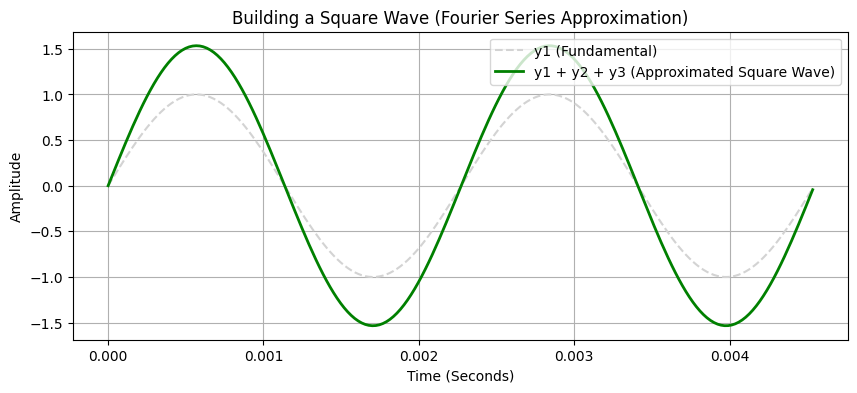

เสียงที่เกิดจากการผสมคลื่น (Synthesis):


In [19]:
f_base = 440.0 # ความถี่หลัก (Fundamental Frequency)

# 1. สร้าง Sine wave ตัวหลัก (ความถี่ f_base, ความดัง 1.0)
y1 = 1.0 * np.sin(2 * np.pi * f * t)

# 2. สร้าง Sine wave ตัวที่ 2 (ความถี่เป็น 3 เท่า, ความดังลดลงเหลือ 1/3)
y2 = 1/3 * np.sin(2 * np.pi * f * t)

# MISSION 4: สร้าง Sine wave ตัวที่ 3 (ความถี่เป็น 5 เท่า, ความดังลดลงเหลือ 1/5)
y3 = 1/5 * np.sin(2 * np.pi * f * t)

# นำคลื่นทั้ง 3 มารวมร่างกัน!
y_fourier =  y1 +  y2 + y3

# พล็อตกราฟเปรียบเทียบคลื่นต้นฉบับ กับคลื่นที่รวมร่างแล้ว
plt.figure(figsize=(10, 4))
plt.plot(t[:201], y1[:201], color='lightgray', linestyle='--', label='y1 (Fundamental)')
plt.plot(t[:201], y_fourier[:201], color='green', linewidth=2, label='y1 + y2 + y3 (Approximated Square Wave)')
plt.title("Building a Square Wave (Fourier Series Approximation)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# ฟังเสียง 8-bit ที่คุณเพิ่งสร้างขึ้นมาจากการผสมคลื่น
print("เสียงที่เกิดจากการผสมคลื่น (Synthesis):")
display(Audio(data=y_fourier, rate=fs))

---
## ภารกิจที่ 5: โลกแห่งความเป็นจริงย่อมมีรอยด่างพร้อย (Adding Noise)
ในโลกความเป็นจริง สัญญาณแทบทุกชนิดมี "สัญญาณรบกวน" (Noise) ปะปนอยู่เสมอ เช่น เสียงซ่าจากไมโครโฟน หรือคลื่นแทรก เราจะมาลองสร้าง White Noise แล้วนำมาผสมกับเสียงเดิมกัน

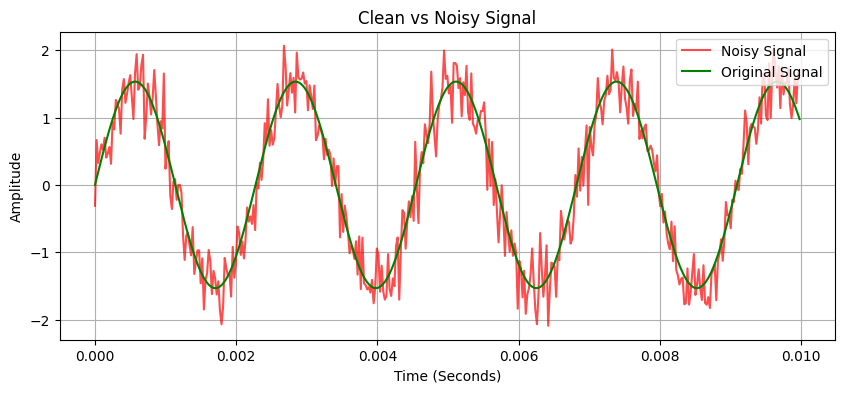

เสียงที่ปนเปื้อน Noise:


In [12]:
# สร้าง White Noise (สัญญาณสุ่มแบบ Gaussian distribution)
noise_amplitude = 0.3 # ปรับความดังของ Noise
noise = noise_amplitude * np.random.normal(0, 1, len(t))

# MISSION 5: นำสัญญาณคลื่นรวม (y_fourier) มาบวกกับสัญญาณรบกวน (noise)
y_noisy = y_fourier + noise

# วาดกราฟเปรียบเทียบ
plt.figure(figsize=(10, 4))
plt.plot(t[:441], y_noisy[:441], color='red', alpha=0.7, label='Noisy Signal')
plt.plot(t[:441], y_fourier[:441], color='green', label='Original Signal')
plt.title("Clean vs Noisy Signal")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# ฟังเสียงที่โดน Noise รบกวน
print("เสียงที่ปนเปื้อน Noise:")
display(Audio(data=y_noisy, rate=fs))

> *จัดทำโดย [Living Incognito]*
> *วิชา ICE385 COMPUTER TECHNOLOGY LABORATORY I (Introduction to Digital Signal Processing) - 13 Mar 2026*